## Overview

This project looks at crop production data for Ghana from 2013 to 2017. It cleans the raw data, explores it with simple charts, and then groups districts into farming types using clustering. The result is a small set of district groups, such as Root and tuber belt or Northern cereal-legume, that describe how each district actually farms, based on the data rather than on assumptions.

The project is built to be readable by a beginner and useful to a recruiter at the same time. The code favors clear function names and short steps over clever shortcuts. The Power BI dashboard that follows this analysis is deliberately small: four pages, a few charts each, built to be understood in under two minutes.

## Import the tools we need

In [1]:
# pandas = working with tables, numpy = math,
# matplotlib = charts, sklearn = the clustering
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RAW_PATH = "Crop Production Data SRID (2).csv"   # <-- change this to your file

## Load the data and look at it

In [2]:
# Read the CSV file into a table called 'raw'
raw = pd.read_csv(RAW_PATH)

# How many rows and columns?
print("Rows and columns:", raw.shape)

# Show the first 5 rows
raw.head()

Rows and columns: (6990, 7)


,REGION,DISTRICT,YEAR,CROP,AREA (Ha),YIELD (Mt/Ha),PRODUCTION (Mt)
0,ASHANTI,Bekwai municipal (Amansie East),2013,Maize,3400.0,2.40,8160.00
1,ASHANTI,Bosome Freho,2013,Maize,2250.0,1.10,2475.00
2,ASHANTI,Amansie Central,2013,Maize,4746.0,1.10,5220.60
3,ASHANTI,Amansie West,2013,Maize,3186.0,2.40,7646.40
4,ASHANTI,Ejura Sekyedumase,2013,Maize,20420.0,1.30,26546.00


In [3]:
# A few problems to notice:
# - duplicate rows exist
# - some numbers are stored as text with spaces, like ' 2.40 '
# - missing values are written as '-'
print("Number of duplicate rows:", raw.duplicated().sum())
print("Example yield values:", list(raw["YIELD (Mt/Ha)"].head(3)))

Number of duplicate rows: 1826
Example yield values: [' 2.40 ', ' 1.10 ', ' 1.10 ']


##  Clean the data

We will:
1. Give the columns shorter names
2. Tidy up the text columns (remove extra spaces)
3. Turn the text numbers into real numbers
4. Remove duplicate rows
5. Fix a few broken production values

In [4]:
# 1. Rename columns to shorter, lower-case names
df = raw.rename(columns={
    "REGION": "region",
    "DISTRICT": "district",
    "YEAR": "year",
    "CROP": "crop",
    "AREA (Ha)": "area_ha",
    "YIELD (Mt/Ha)": "yield_mt_ha",
    "PRODUCTION (Mt)": "production_mt",
})

df.head(3)

,region,district,year,crop,area_ha,yield_mt_ha,production_mt
0,ASHANTI,Bekwai municipal (Amansie East),2013,Maize,3400.0,2.40,8160.00
1,ASHANTI,Bosome Freho,2013,Maize,2250.0,1.10,2475.00
2,ASHANTI,Amansie Central,2013,Maize,4746.0,1.10,5220.60


In [5]:
# 2. Clean the text columns: remove extra spaces and fix the capitalisation
df["region"] = df["region"].str.strip().str.upper()
df["district"] = df["district"].str.strip().str.title()
df["crop"] = df["crop"].str.strip().str.title()

print("Regions found:", df["region"].unique())

Regions found: ['ASHANTI' 'BRONG AHAFO' 'CENTRAL' 'EASTERN' 'GREATER ACCRA' 'NORTHERN'
 'UPPER EAST' 'UPPER WEST' 'VOLTA' 'WESTERN']


In [6]:
# Checking DataTypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6990 entries, 0 to 6989
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   region         6990 non-null   object 
 1   district       6990 non-null   object 
 2   year           6990 non-null   int64  
 3   crop           6990 non-null   object 
 4   area_ha        6990 non-null   float64
 5   yield_mt_ha    6982 non-null   object 
 6   production_mt  6990 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 382.4+ KB


In [7]:
# 3. Turn text numbers into real numbers.
# This small function: removes spaces, turns '-' into "missing",
# then converts to a number.
def to_number(column):
    text = column.astype(str).str.strip()   # remove spaces
    text = text.replace("-", np.nan)         # '-' means missing
    return pd.to_numeric(text, errors="coerce")  # convert to number

df["area_ha"] = to_number(df["area_ha"])
df["yield_mt_ha"] = to_number(df["yield_mt_ha"])
df["production_mt"] = to_number(df["production_mt"])

df.dtypes

region            object
district          object
year               int64
crop              object
area_ha          float64
yield_mt_ha      float64
production_mt    float64
dtype: object

In [8]:
# 4. Remove duplicate rows (rows that are exactly the same)
rows_before = len(df)
df = df.drop_duplicates()
print("Removed", rows_before - len(df), "duplicate rows")
print("Rows left:", len(df))

Removed 1827 duplicate rows
Rows left: 5163


In [9]:
# 5. Fix broken production values.
# Rule: production should equal area * yield.
# A few rows have a wrong production number, so we rebuild it.

# First, if yield is missing but we have production and area, work yield out:
missing_yield = df["yield_mt_ha"].isna() & df["production_mt"].notna() & (df["area_ha"] > 0)
df.loc[missing_yield, "yield_mt_ha"] = df["production_mt"] / df["area_ha"]

# Keep the old production so we can see which rows we changed
old_production = df["production_mt"].copy()

# Rebuild production from area * yield
df["production_mt"] = (df["area_ha"] * df["yield_mt_ha"]).round(2)

# Mark the rows where the original was clearly wrong (off by more than 5%)
difference = (df["production_mt"] - old_production).abs()
df["production_corrected"] = difference > (0.05 * df["production_mt"])

print("Rows with a corrected production value:", df["production_corrected"].sum())
df = df.reset_index(drop=True)
df.head(3)

Rows with a corrected production value: 39


,region,district,year,crop,area_ha,yield_mt_ha,production_mt,production_corrected
0,ASHANTI,Bekwai Municipal (Amansie East),2013,Maize,3400.0,2.4,8160.0,False
1,ASHANTI,Bosome Freho,2013,Maize,2250.0,1.1,2475.0,False
2,ASHANTI,Amansie Central,2013,Maize,4746.0,1.1,5220.6,False


In [10]:
# Our clean dataset
print("Final clean rows:", len(df))
print("Regions:", df["region"].nunique())
print("Districts:", df["district"].nunique())
print("Crops:", df["crop"].nunique())

Final clean rows: 5163
Regions: 10
Districts: 226
Crops: 11


## Explore the data with charts

First we group crops into 3 families so they are easier to compare.

In [11]:
# Label each crop as a cereal, root crop, or legume
crop_family = {
    "Maize": "cereal", "Rice": "cereal", "Millet": "cereal", "Sorghum": "cereal",
    "Cassava": "root", "Yam": "root", "Cocoyam": "root", "Plantain": "root",
    "Cowpea": "legume", "Groundnut": "legume", "Soyabean": "legume",
}
df["crop_group"] = df["crop"].map(crop_family)

# The big-picture numbers
total_production = df["production_mt"].sum()
total_area = df["area_ha"].sum()
print("Total production: {:,.0f} tonnes".format(total_production))
print("Total area:       {:,.0f} hectares".format(total_area))
print("Average yield:    {:.2f} tonnes per hectare".format(total_production / total_area))

Total production: 162,000,913 tonnes
Total area:       18,799,636 hectares
Average yield:    8.62 tonnes per hectare


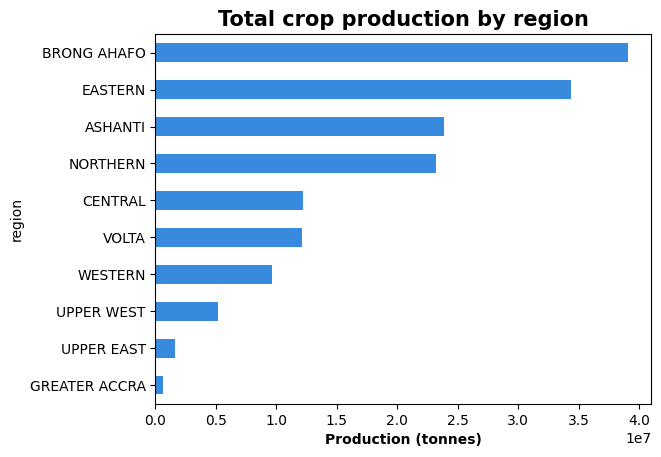

In [13]:
# Chart 1: total production for each region
production_by_region = df.groupby("region")["production_mt"].sum()
production_by_region = production_by_region.sort_values()

production_by_region.plot(kind="barh", color="#378ADD")
plt.title("Total crop production by region",fontweight='bold',fontsize=15)
plt.xlabel("Production (tonnes)",fontweight='bold')
plt.show()

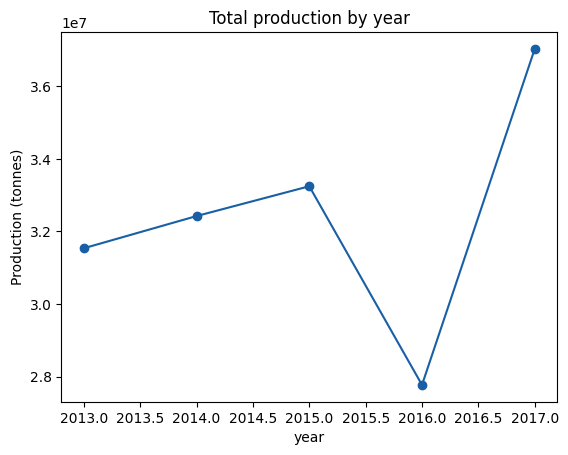

In [15]:
# Chart 2: total production each year (2016 has less data)
production_by_year = df.groupby("year")["production_mt"].sum()

production_by_year.plot(kind="line", marker="o", color="#185FA5")
plt.title("Total production by year")
plt.ylabel("Production (tonnes)")
plt.show()

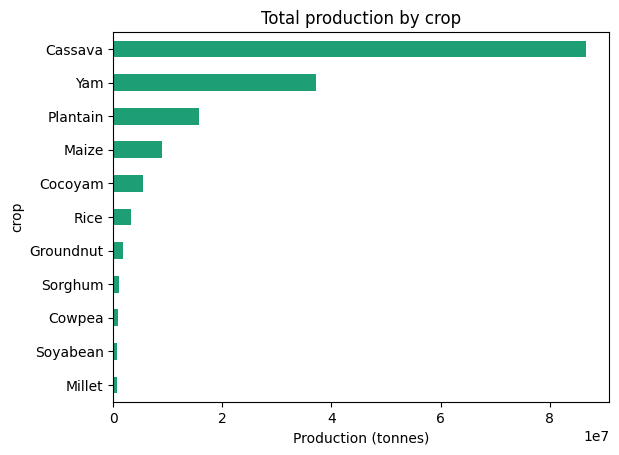

In [16]:
# Chart 3: which crops produce the most?
production_by_crop = df.groupby("crop")["production_mt"].sum()
production_by_crop = production_by_crop.sort_values()

production_by_crop.plot(kind="barh", color="#1D9E75")
plt.title("Total production by crop")
plt.xlabel("Production (tonnes)")
plt.show()

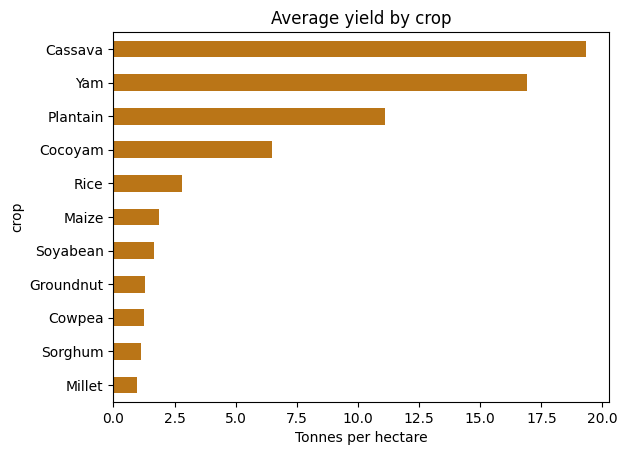

In [17]:
# Chart 4: average yield for each crop
# (total production divided by total area, per crop)
prod_per_crop = df.groupby("crop")["production_mt"].sum()
area_per_crop = df.groupby("crop")["area_ha"].sum()
yield_per_crop = (prod_per_crop / area_per_crop).sort_values()

yield_per_crop.plot(kind="barh", color="#BA7517")
plt.title("Average yield by crop")
plt.xlabel("Tonnes per hectare")
plt.show()

## Group districts into farming types (clustering)

For each district we build a small profile:
- how much of its land grows cereals, roots, and legumes
- its average yield
- its total size
- how many different crops it grows

Then we let K-means find the natural groups.

In [18]:
# Build one row of numbers per district using a simple loop.
district_rows = []

for (region_name, district_name), group in df.groupby(["region", "district"]):
    total_area_here = group["area_ha"].sum()
    total_prod_here = group["production_mt"].sum()

    if total_area_here <= 0:
        continue  # skip districts with no area

    # area used by each crop family
    area_by_family = group.groupby("crop_group")["area_ha"].sum()
    cereal_area = area_by_family.get("cereal", 0)
    root_area = area_by_family.get("root", 0)
    legume_area = area_by_family.get("legume", 0)

    district_rows.append({
        "region": region_name,
        "district": district_name,
        "cereal_share": cereal_area / total_area_here,
        "root_share": root_area / total_area_here,
        "legume_share": legume_area / total_area_here,
        "avg_yield": total_prod_here / total_area_here,
        "size_log": np.log10(total_area_here),   # log keeps big and small comparable
        "num_crops": group["crop"].nunique(),
        "total_area": total_area_here,
        "total_production": total_prod_here,
    })

districts = pd.DataFrame(district_rows)
print("Districts profiled:", len(districts))
districts.head()

Districts profiled: 226


,region,district,cereal_share,root_share,legume_share,avg_yield,size_log,num_crops,total_area,total_production
0,ASHANTI,Adansi South (East),0.311193,0.688807,0.000000,11.646554,4.933204,6,85744.04,998622.62
1,ASHANTI,Adansi North,0.237150,0.762850,0.000000,12.827835,4.899328,6,79309.97,1017375.17
2,ASHANTI,Afigya Kwabre,0.255247,0.740582,0.004171,11.061385,4.774397,8,59483.55,657970.46
3,ASHANTI,Ahafo Ano North,0.338300,0.659640,0.002060,8.917336,5.152094,7,141936.55,1265695.95
4,ASHANTI,Ahafo Ano South,0.269248,0.730752,0.000000,10.761551,5.256043,6,180319.80,1940520.64


In [19]:
# Pick the columns we cluster on
feature_columns = ["cereal_share", "root_share", "legume_share",
                   "avg_yield", "size_log", "num_crops"]

# Rescale so every column counts equally (big numbers don't dominate)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(districts[feature_columns])

In [20]:
# How many groups (k) should we use?
# The silhouette score tells us how clean a grouping is (higher = better).
print("k : silhouette score")
for k in range(2, 8):
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = model.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    print(k, ":", round(score, 3))

k : silhouette score
2 : 0.475
3 : 0.428
4 : 0.287
5 : 0.3
6 : 0.287
7 : 0.281


In [21]:
# We use 4 groups: clean enough, and gives useful detail.
model = KMeans(n_clusters=4, n_init=10, random_state=42)
districts["cluster"] = model.fit_predict(scaled_features)

# See how many districts landed in each group
districts["cluster"].value_counts()

cluster
0    94
1    66
3    52
2    14
Name: count, dtype: int64

In [22]:
# Give each group an easy-to-read name based on what it looks like.
def name_the_group(row):
    if row["total_area"] < 2000 and row["cereal_share"] > 0.6:
        return "Urban / peri-urban"
    if row["root_share"] >= 0.6:
        return "Root & tuber belt"
    if row["legume_share"] >= 0.20 and row["cereal_share"] >= 0.45:
        return "Northern cereal-legume"
    if row["cereal_share"] >= 0.40 and row["root_share"] >= 0.30:
        return "Mixed transitional"
    return "Other"

# Work out the average profile of each group
group_profile = districts.groupby("cluster")[
    ["cereal_share", "root_share", "legume_share", "avg_yield", "total_area"]
].mean()

# Name each group
group_names = {}
for cluster_number, profile_row in group_profile.iterrows():
    group_names[cluster_number] = name_the_group(profile_row)

districts["group_name"] = districts["cluster"].map(group_names)

# Show the profile with names
group_profile["name"] = group_profile.index.map(group_names)
group_profile.round(2)

,cereal_share,root_share,legume_share,avg_yield,total_area,name
cluster,,,,,,
0,0.28,0.70,0.02,12.31,92976.64,Root & tuber belt
1,0.44,0.55,0.00,8.61,51676.80,Mixed transitional
2,0.78,0.20,0.02,4.61,4750.39,Other
3,0.54,0.15,0.30,3.43,126589.55,Northern cereal-legume


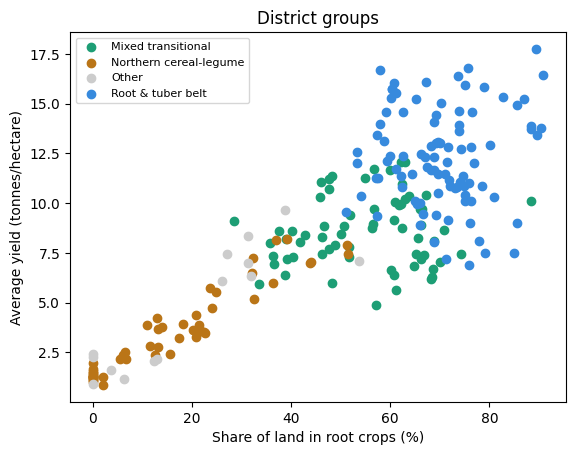

In [23]:
# Draw the groups using two of the features
group_colors = {
    "Root & tuber belt": "#378ADD",
    "Mixed transitional": "#1D9E75",
    "Northern cereal-legume": "#BA7517",
    "Urban / peri-urban": "#888780",
    "Other": "#cccccc",
}

for group_name, group_data in districts.groupby("group_name"):
    plt.scatter(group_data["root_share"] * 100,
                group_data["avg_yield"],
                label=group_name,
                color=group_colors.get(group_name))

plt.xlabel("Share of land in root crops (%)")
plt.ylabel("Average yield (tonnes/hectare)")
plt.title("District groups")
plt.legend(fontsize=8)
plt.show()

In [24]:
# Which regions are in each group?
pd.crosstab(districts["region"], districts["group_name"])

group_name,Mixed transitional,Northern cereal-legume,Other,Root & tuber belt
region,,,,
ASHANTI,4,1,0,23
BRONG AHAFO,9,2,1,21
CENTRAL,14,0,0,4
EASTERN,3,0,0,24
GREATER ACCRA,4,0,7,0
NORTHERN,0,24,0,4
UPPER EAST,0,14,2,0
UPPER WEST,0,11,0,0
VOLTA,17,0,4,7


## Save the results

In [29]:
# Save the district groups
districts.to_csv("district_clusters.csv", index=False)

# Add the group name onto the main clean data and save it too
df_with_groups = df.merge(
    districts[["region", "district", "cluster", "group_name"]],
    on=["region", "district"],
    how="left",
)
df_with_groups.to_csv("crop_clean.csv", index=False)

df_with_groups.shape
print("Saved crop_clean.csv and district_clusters.csv")

Saved crop_clean.csv and district_clusters.csv


In [31]:
df_with_groups.shape

(5163, 11)

## Things to remember

- The data is only from **2013 to 2017**, and **2016 has less data**.
- Regions are the **old 10 regions** (before Ghana split into 16 in 2018).
- A few production numbers were rebuilt because the originals were clearly wrong.
- The grouping uses all years together, so it shows the *type* of farming in each district,
  not how it changed over time.